<a href="https://colab.research.google.com/github/cristinasarakefi-art/TugasAkhirS1/blob/main/Penelitian%209%20fix%20Untitled24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Setting tampilan visualisasi
sns.set_theme(style="whitegrid")
print("=== 1. LIBRARY BERHASIL DIIMPOR ===")

=== 1. LIBRARY BERHASIL DIIMPOR ===


In [2]:
#Membaca Dataset dari file csv
nama_file = '/content/Data Mentah Penelitian Skripsi 3.csv'

In [3]:
# Membaca dataset dengan pemisah titik-koma (;) dan desimal koma (,)
df = pd.read_csv(nama_file, sep=';', decimal=',')
df['Bidang Minat'] = df['Bidang Minat'].astype(str).str.strip()

print(f"\n=== 2. MEMBACA FILE DATASET '{nama_file}' ===")
print(f"Total Data Mahasiswa : {df.shape[0]} Baris")
print(f"Total Kolom Variabel : {df.shape[1]} Kolom\n")
print("5 Baris Pertama Data:")
display(df.head())


=== 2. MEMBACA FILE DATASET '/content/Data Mentah Penelitian Skripsi 3.csv' ===
Total Data Mahasiswa : 100 Baris
Total Kolom Variabel : 9 Kolom

5 Baris Pertama Data:


,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai Matkul DTL,Nilai Matkul DTT,Nilai Matkul DPK,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
0,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,2.79,4.00,2.00,2.00,15,15,29
1,Kartini Riyani Boni Geti,Teknik Telekomunikasi,2.79,3.75,2.75,2.25,17,27,25
2,Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,2.73,4.00,3.25,3.50,30,35,32
3,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,2.48,3.50,2.75,2.00,20,7,33
4,Epin Modjo,Teknik Komputer & Kendali,2.91,3.25,2.75,3.50,29,21,35


In [6]:

# Membaca dataset dengan pemisah titik-koma (;) dan desimal koma (,)
df = pd.read_csv(nama_file, sep=';', decimal=',')
df['Bidang Minat'] = df['Bidang Minat'].astype(str).str.strip()

print(f"\n=== 2. MEMBACA FILE DATASET '{nama_file}' ===")
print(f"Total Data Mahasiswa : {df.shape[0]} Baris")
print(f"Total Kolom Variabel : {df.shape[1]} Kolom\n")
print("5 Baris Pertama Data:")
display(df.head())


=== 2. MEMBACA FILE DATASET '/content/Data Mentah Penelitian Skripsi 3.csv' ===
Total Data Mahasiswa : 100 Baris
Total Kolom Variabel : 9 Kolom

5 Baris Pertama Data:


,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai Matkul DTL,Nilai Matkul DTT,Nilai Matkul DPK,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
0,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,2.79,4.00,2.00,2.00,15,15,29
1,Kartini Riyani Boni Geti,Teknik Telekomunikasi,2.79,3.75,2.75,2.25,17,27,25
2,Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,2.73,4.00,3.25,3.50,30,35,32
3,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,2.48,3.50,2.75,2.00,20,7,33
4,Epin Modjo,Teknik Komputer & Kendali,2.91,3.25,2.75,3.50,29,21,35


In [8]:
# Pra Pemrosesan Data
# Fungsi Manual Min-Max Scaling Sesuai Rumus Persamaan (3.1) di Bab III
def min_max_scaling(val, min_val, max_val):
    return (val - min_val) / (max_val - min_val)


# Mengaplikasikan Normalisasi Min-Max Scaling (Skala 0 - 1)
# Rentang IPK dan Nilai Matkul (0 sampai 4)
# Rentang Skor Kuesioner Minat (7 sampai 35)
df['Norm_IPK'] = min_max_scaling(df['IPK Semester 3'], 0, 4) if df['IPK Semester 3'].max() > 1 else df['IPK Semester 3']
df['Norm_DTL'] = min_max_scaling(df['Nilai Matkul DTL'], 0, 4) if df['Nilai Matkul DTL'].max() > 1 else df['Nilai Matkul DTL']
df['Norm_DTT'] = min_max_scaling(df['Nilai Matkul DTT'], 0, 4) if df['Nilai Matkul DTT'].max() > 1 else df['Nilai Matkul DTT']
df['Norm_DPK'] = min_max_scaling(df['Nilai Matkul DPK'], 0, 4) if df['Nilai Matkul DPK'].max() > 1 else df['Nilai Matkul DPK']

df['Norm_Skor_TTL'] = min_max_scaling(df['Nilai Skor Minat TTL'], 7, 35) if df ['Nilai Skor Minat TTL'].max() > 1 else df['Nilai Skor Minat TTL']
df['Norm_Skor_TTT'] = min_max_scaling(df['Nilai Skor Minat TTT'], 7, 35) if df ['Nilai Skor Minat TTT'].max() > 1 else df['Nilai Skor Minat TTT']
df['Norm_Skor_TKK'] = min_max_scaling(df['Nilai Skor Minat TKK'], 7, 35) if df ['Nilai Skor Minat TKK'].max() > 1 else df['Nilai Skor Minat TKK']

# Mengelompokkan Fitur Input yang Sudah Ter-normalisasi
fitur_input = ['Norm_IPK', 'Norm_DTL', 'Norm_DTT', 'Norm_DPK', 'Norm_Skor_TTL', 'Norm_Skor_TTT', 'Norm_Skor_TKK']

X = df[fitur_input]
y = df['Bidang Minat']

print("Statistik Hasil Normalisasi Min-Max Scaling (Interval 0 sampai 1):")
display(X.describe().T[['min', 'max', 'std']])

Statistik Hasil Normalisasi Min-Max Scaling (Interval 0 sampai 1):


,min,max,std
Norm_IPK,0.520000,0.9875,0.089714
Norm_DTL,0.312500,1.0000,0.126169
Norm_DTT,0.000000,1.0000,0.178398
Norm_DPK,0.500000,1.0000,0.165873
Norm_Skor_TTL,0.000000,1.0000,0.229818
Norm_Skor_TTT,0.000000,1.0000,0.239841
Norm_Skor_TKK,0.071429,1.0000,0.229052


In [9]:
#Pembagian Data Berurutan
X_train = X.iloc[:80]
X_test  = X.iloc[80:]
y_train = y.iloc[:80]
y_test  = y.iloc[80:]

print("\n=== 4. PEMBAGIAN DATA SET BERURUTAN (80:20) ===")
print(f"Data Latih (Baris 1 - 80)   : {len(X_train)} Mahasiswa")
print(f"Data Uji   (Baris 81 - 100) : {len(X_test)} Mahasiswa")


=== 4. PEMBAGIAN DATA SET BERURUTAN (80:20) ===
Data Latih (Baris 1 - 80)   : 80 Mahasiswa
Data Uji   (Baris 81 - 100) : 20 Mahasiswa


In [10]:
#Simulasi perhitungan jarak & pengurutan ascending data uji 1
# Ambil sampel Data Uji 1 (indeks ke-80)
sampel_uji_1 = X_test.iloc[0]

# Hitung jarak Euclidean terhadap 80 data latih
jarak_list = []
for i in range(len(X_train)):
    d = np.sqrt(np.sum((sampel_uji_1 - X_train.iloc[i]) ** 2))
    jarak_list.append({
        'Indeks Data Latih': i + 1,
        'Nama Mahasiswa': df.iloc[i]['Nama Lengkap'],
        'Peminatan': y_train.iloc[i],
        'Euclidean Distance': round(d, 4)
    })

df_jarak = pd.DataFrame(jarak_list)

# Urutkan jarak dari yang terpendek hingga terpanjang (Ascending)
df_jarak_sorted = df_jarak.sort_values(by='Euclidean Distance', ascending=True).reset_index(drop=True)

print("\n11 Tetangga Terdekat untuk Data Uji 1 (K = 11 Ascending):")
display(df_jarak_sorted.head(11))


11 Tetangga Terdekat untuk Data Uji 1 (K = 11 Ascending):


,Indeks Data Latih,Nama Mahasiswa,Peminatan,Euclidean Distance
0,10,GERSON YULIUS MARIA NAHAK,Teknik Komputer & Kendali,0.1826
1,55,Yohana Palestrina Kobesi,Teknik Komputer & Kendali,0.2298
2,26,Yedija Wiliems Mooy,Teknik Komputer & Kendali,0.2472
3,5,Epin Modjo,Teknik Komputer & Kendali,0.4035
4,79,Regina Ilon Fernandes,Teknik Komputer & Kendali,0.4602
5,1,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,0.4694
6,4,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,0.5053
7,11,Andre Namah,Teknik Komputer & Kendali,0.5142
8,16,cristo sutiray,Teknik Komputer & Kendali,0.5386
9,15,Diana Banunaek,Teknik Komputer & Kendali,0.5409


---------------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 3
---------------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.86      0.86      0.86         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
Teknik Komputer & Kendali       1.00      0.86      0.92         7

                 accuracy                           0.90        20
                macro avg       0.90      0.90      0.90        20
             weighted avg       0.91      0.90      0.90        20



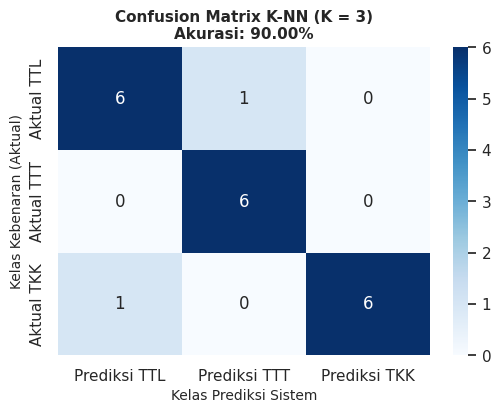

---------------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 5
---------------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.86      0.86      0.86         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
Teknik Komputer & Kendali       1.00      0.86      0.92         7

                 accuracy                           0.90        20
                macro avg       0.90      0.90      0.90        20
             weighted avg       0.91      0.90      0.90        20



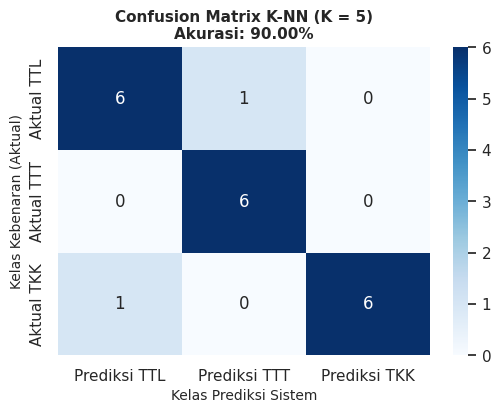

---------------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 7
---------------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.86      0.86      0.86         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
Teknik Komputer & Kendali       1.00      0.86      0.92         7

                 accuracy                           0.90        20
                macro avg       0.90      0.90      0.90        20
             weighted avg       0.91      0.90      0.90        20



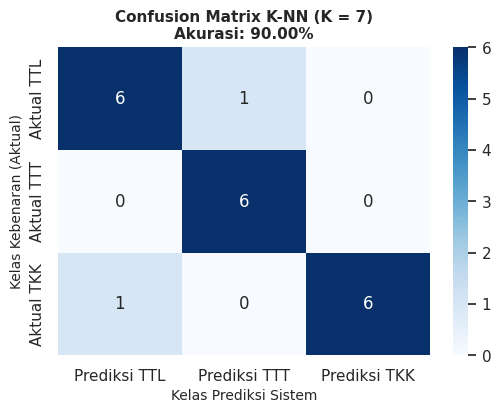

---------------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 9
---------------------------------------------------------------------------
Akurasi Sistem : 85.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.75      0.86      0.80         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
Teknik Komputer & Kendali       1.00      0.71      0.83         7

                 accuracy                           0.85        20
                macro avg       0.87      0.86      0.85        20
             weighted avg       0.87      0.85      0.85        20



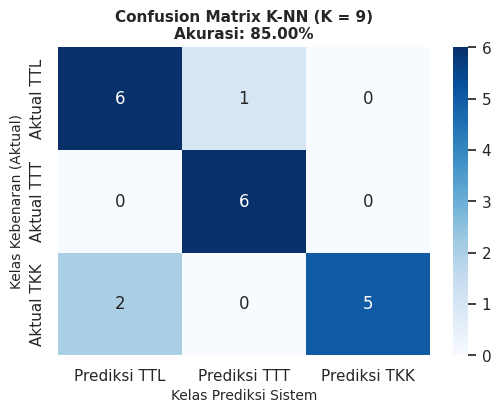

---------------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 11
---------------------------------------------------------------------------
Akurasi Sistem : 85.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.75      0.86      0.80         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
Teknik Komputer & Kendali       1.00      0.71      0.83         7

                 accuracy                           0.85        20
                macro avg       0.87      0.86      0.85        20
             weighted avg       0.87      0.85      0.85        20



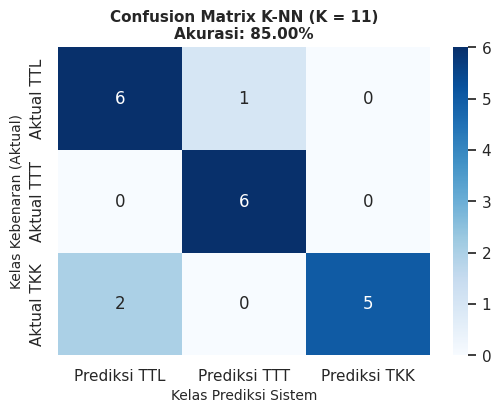


=== TABEL REKAPITULASI HASIL AKURASI PER K ===


,Nilai K,Akurasi Sistem (%),Prediksi Benar
0,K = 3,90.00%,18 / 20 Data
1,K = 5,90.00%,18 / 20 Data
2,K = 7,90.00%,18 / 20 Data
3,K = 9,85.00%,17 / 20 Data
4,K = 11,85.00%,17 / 20 Data


In [13]:
# TAHAP 6: KLASIFIKASI K-NN, EVALUASI & GENERATE CONFUSION MATRIX (K = 3, 5, 7, 9, 11)
label_kelas = ['Teknik Tenaga Listrik', 'Teknik Telekomunikasi', 'Teknik Komputer & Kendali']
variasi_k = [3, 5, 7, 9, 11]
rekap_performa = []

for k in variasi_k:
    # Model K-NN dengan weights='uniform' dan Euclidean Distance
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='euclidean')
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Hitung Akurasi dan Confusion Matrix
    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred, labels=label_kelas)

    rekap_performa.append({
        'Nilai K': f"K = {k}",
        'Akurasi Sistem (%)': f"{acc:.2f}%",
        'Prediksi Benar': f"{np.trace(cm)} / {len(y_test)} Data"
    })

    print("-" * 75)
    print(f"               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = {k}")
    print("-" * 75)
    print(f"Akurasi Sistem : {acc:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, labels=label_kelas, zero_division=0))

    # Visualisasi Heatmap Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Prediksi TTL', 'Prediksi TTT', 'Prediksi TKK'],
                yticklabels=['Aktual TTL', 'Aktual TTT', 'Aktual TKK'])

    plt.title(f'Confusion Matrix K-NN (K = {k})\nAkurasi: {acc:.2f}%', fontsize=11, fontweight='bold')
    plt.ylabel('Kelas Kebenaran (Aktual)', fontsize=10)
    plt.xlabel('Kelas Prediksi Sistem', fontsize=10)

    nama_gambar = f'confusion_matrix_K_{k}.png'
    plt.savefig(nama_gambar, dpi=300, bbox_inches='tight')
    plt.show()

# Display Tabel Rekapitulasi Akurasi
print("\n=== TABEL REKAPITULASI HASIL AKURASI PER K ===")
display(pd.DataFrame(rekap_performa))


Hasil Rata-rata Akurasi 5-Fold Cross Validation:


,Nilai K,Rata-Rata Akurasi
0,K = 3,92.0
1,K = 5,90.0
2,K = 7,90.0
3,K = 9,91.0
4,K = 11,94.0


/tmp/ipykernel_3687/2571056271.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


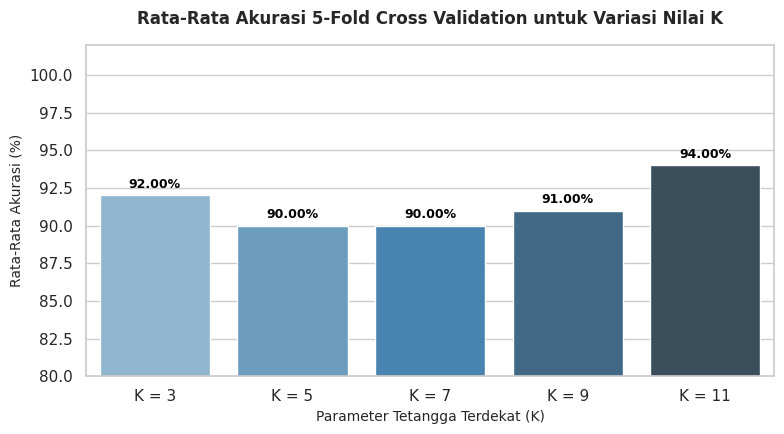

In [12]:
# TAHAP 7: PENGUJIAN & GRAFIK 5-FOLD CROSS VALIDATION (5 BATANG)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rata_rata_cv = []

for k in variasi_k:
    knn_cv = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='euclidean')
    scores = cross_val_score(knn_cv, X, y, cv=skf)
    rata_rata_cv.append({
        'Nilai K': f'K = {k}',
        'Rata-Rata Akurasi': scores.mean() * 100
    })

df_cv_mean = pd.DataFrame(rata_rata_cv)

print("\nHasil Rata-rata Akurasi 5-Fold Cross Validation:")
display(df_cv_mean)

# Visualisasi Grafik 5 Batang
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=df_cv_mean,
    x='Nilai K',
    y='Rata-Rata Akurasi',
    palette='Blues_d'
)

plt.title('Rata-Rata Akurasi 5-Fold Cross Validation untuk Variasi Nilai K', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Parameter Tetangga Terdekat (K)', fontsize=10)
plt.ylabel('Rata-Rata Akurasi (%)', fontsize=10)
plt.ylim(80, 102)

# Menambahkan angka persentase di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='black',
                xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('grafik_5_batang_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()
